# Origins of replication pre-analysis

From the raw MNase:
- Compute the total occupancy, origin occupancy (small fragments), and non origin occupancy (mostly nucleosomal).
- Compute the peak position of the small origin occupancy location.
- Plot the distribution of the total occupancies and determine a threshold to remove low coverage origins
- Plot the distribution of the proportion of small fragment reads to determine a threshold in which we do not identify an origin footprint.
- Create a column that labels the origins as having called footprints in our dataset.
- Save the constructed dataframe.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [390]:
from pipeline.precompute_origin_analysis import OriginFootprintAnalysis

window = 1000
origin_analysis = OriginFootprintAnalysis(window_size=window)

In [391]:
origins = origin_analysis.load_origin_reference_dataset()

In [393]:
_ = origin_analysis.collect_origin_histograms()

Processing origin 1/798 - 00:00:00.001
Processing origin 101/798 - 00:00:19.699
Processing origin 201/798 - 00:00:46.693
Processing origin 301/798 - 00:01:15.011
Processing origin 401/798 - 00:01:38.594
Processing origin 501/798 - 00:02:08.688
Processing origin 601/798 - 00:02:26.344
Processing origin 701/798 - 00:02:53.799
Completed histogram collection for 798 origins in both replicates - 00:03:10.696


In [466]:
def create_origins_subset_mean_df(histogram_dict_data, origins, frag_sel=(0, 100),
                                 window=1000, strand_correct=True):
    """Create a dataframe of the origins histogram data, size selected"""

    origin_hists_mat_rep1 = np.array(list(histogram_dict_data.values()))

    win_2 = window//2
    origin_small_fragment_means1 = origin_hists_mat_rep1[:, 
        frag_sel[0]:frag_sel[1], :].mean(axis=1)
    origins_small_rep1_df = pd.DataFrame(origin_small_fragment_means1, 
        index=origins.index,
                columns=np.arange(-win_2, win_2+1))
    
    # Flip the genomic position for origins that bind to the crick strand
    if strand_correct:
        crick_indices = origins[origins.strand == '-'].index
        origins_small_rep1_df.loc[crick_indices, :] = \
            np.flip(origins_small_rep1_df.loc[crick_indices, :].values, axis=1)
    
    return origins_small_rep1_df


In [467]:
small_mean_rep1_df = create_origins_subset_mean_df(origin_analysis.histograms_rep1, origins,
    strand_correct=True)
small_mean_rep2_df = create_origins_subset_mean_df(origin_analysis.histograms_rep1, origins,
    strand_correct=True)

In [468]:
origins[origins.footprint_class == 'g1_and_g2_footprint']

sorted_origins = origin_analysis.origins.copy()
sorted_origins['sort_metric'] = sorted_origins.footprint_class == 'g1_and_g2_footprint'
sorted_origins = sorted_origins.sort_values(
    'sort_metric', ascending=False)
sorted_indices = sorted_origins.index


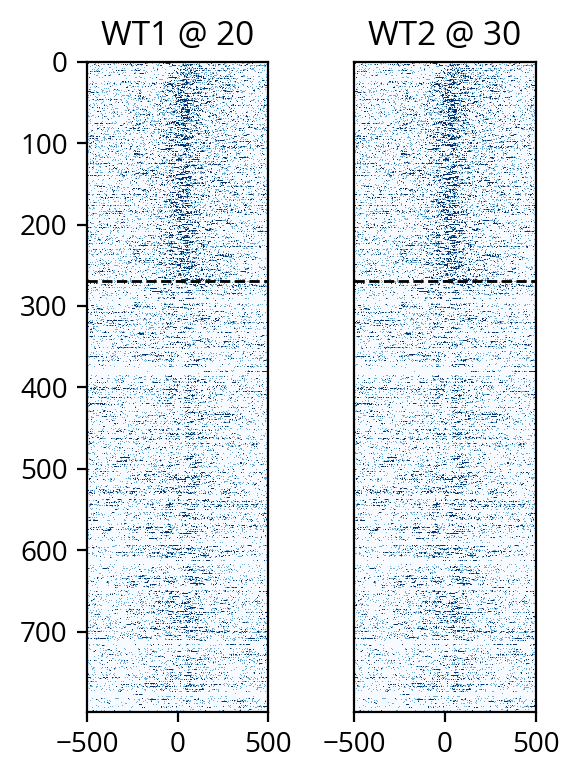

In [472]:
def plot_im(ax, dat):
    n = len(dat)
    ax.imshow(dat, vmax=0.02, aspect='auto',
              extent=[-win_2, win_2, 0, n], origin='lower', interpolation='none',
              cmap='Blues')
    ax.set_ylim(n, 0)

fig, axs = plt.subplots(1, 2, figsize=(3, 4))
num_footprint = sum(sorted_origins.footprint_class == 'g1_and_g2_footprint')
    
plot_im(axs[0], small_mean_rep1_df.loc[sorted_indices])
axs[0].set_title("WT1 @ 20")
axs[0].axhline(num_footprint, c='black', lw=1, ls='dashed')

plot_im(axs[1], small_mean_rep2_df.loc[sorted_indices])
axs[1].set_title("WT2 @ 30")
axs[1].set_yticks([])
axs[1].axhline(num_footprint, c='black', lw=1, ls='dashed')

# Examine the deconvolved data for these origin positions.

# Plot the heatmaps for these, in the same order, at middle of G1, start of S, and end of G2
# This will give us an idea of how these origins change over time

# Do this for the raw data as well:  0, 30, 60
#                              and:  0, 20, 50       
# Expect 0-recovery, 20-S-phase, 50-G2 end of replication
plt.tight_layout()

In [512]:
def retrieve_composite_data(dict_data, subset_origins, strand_correct=True):
    subset_origins = subset_origins.copy()
    subset_keys = subset_origins.index
    subset_dict_data = {k: dict_data[k] for k in subset_keys if k in original_dict}

    footprint_histograms = np.array(list(subset_dict_data.values()))

    # The composite data is in a 3d array, so we need to index it numerically
    subset_origins['array_index'] = np.arange(len(subset_origins))
    crick_origins_index = subset_origins[subset_origins.strand == '-'].array_index.values

    flipped_footprint_hists = footprint_histograms.copy()
    if strand_correct:
        flipped_footprint_hists[crick_origins_index] = np.flip(footprint_histograms[crick_origins_index], 
        axis=2)
    footprint_composite = flipped_footprint_hists.mean(axis=0)
    return footprint_composite


Text(0.5, 1.0, 'WT2 @ 20')

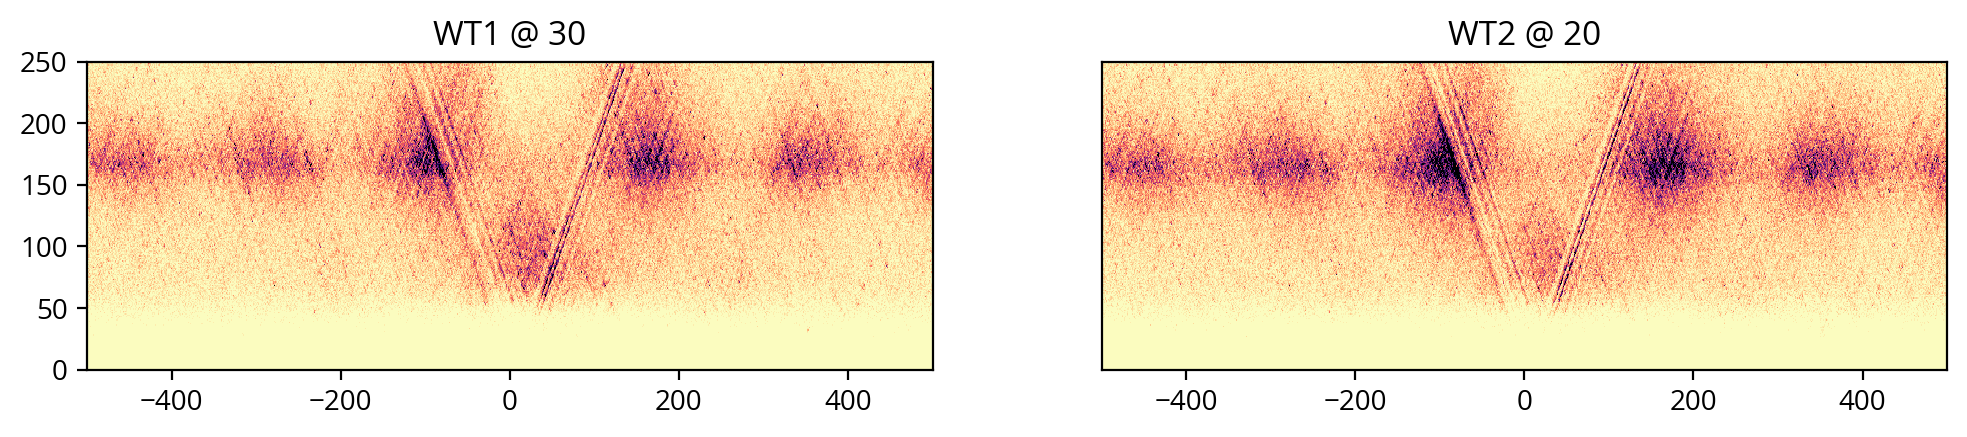

In [520]:
footprint_origins = sorted_origins[sorted_origins.footprint_class =='g1_and_g2_footprint']

composite_mat1 = retrieve_composite_data(origin_analysis.histograms_rep1,
                       footprint_origins)
composite_mat2 = retrieve_composite_data(origin_analysis.histograms_rep2,
                       footprint_origins)

def plot_im_composite(ax, footprint_composite):
    ax.imshow(footprint_composite, cmap='magma_r', origin='lower', vmax=0.1,
              extent=[-win_2, win_2, 0, 250], aspect='auto', interpolation='none')
    
fig, axs = plt.subplots(1, 2, figsize=(12, 2))

plot_im_composite(axs[0], composite_mat1)
axs[0].set_title('WT1 @ 30')
plot_im_composite(axs[1], composite_mat2)
axs[1].set_yticks([])
axs[1].set_title('WT2 @ 20')

#plt.tight_layout()